#### ***Deep Learning Fundamentals Day 70 📊***
***
-  ***ANN For Regression***

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [2]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [3]:
X = df.drop("PE",axis=1)
y = df["PE"]

In [4]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [5]:
## Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
print(len(X_train), len(y_train))
print(len(X_test), len(y_test))

7654 7654
1914 1914


In [7]:
df.shape

(9568, 5)

In [8]:
X_train.head

<bound method NDFrame.head of          AT      V       AP     RH
5487  25.24  63.47  1011.30  66.21
3522  26.09  70.40  1007.41  85.37
6916  26.63  73.68  1015.15  85.13
7544  32.06  71.85  1007.90  56.44
7600  28.70  71.64  1007.11  69.85
...     ...    ...      ...    ...
5734  26.25  61.02  1011.47  71.22
5191  29.17  64.79  1016.43  61.05
5390  18.00  43.70  1015.40  61.28
860   26.73  68.84  1010.75  66.83
7270   6.40  39.18  1024.60  86.83

[7654 rows x 4 columns]>

In [9]:
X_test.head()

,AT,V,AP,RH
2513,29.70,57.35,1005.63,57.35
9411,25.71,71.64,1008.85,77.31
8745,17.83,44.92,1025.04,70.58
9085,9.46,41.40,1026.78,87.58
4950,29.90,64.79,1016.90,48.24


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [11]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

In [12]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]],
      shape=(1914, 4))

In [13]:
import torch

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32).view(-1,1)
y_test_tensor  = torch.tensor(y_test.to_numpy(), dtype=torch.float32).view(-1,1)

In [14]:
print(X_train_tensor.shape, y_train_tensor.shape)
print(X_test_tensor.shape, y_test_tensor.shape)

torch.Size([7654, 4]) torch.Size([7654, 1])
torch.Size([1914, 4]) torch.Size([1914, 1])


In [15]:
type(X_train_scaled)

numpy.ndarray

In [16]:
type(y_train)

pandas.core.series.Series

In [17]:
from torch.utils.data import TensorDataset,DataLoader
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32)

- ***Deep Learning***

In [18]:
## Define our ANN Model
import torch.nn as nn

class ANN(nn.Module):
     def __init__(self):
          super(ANN,self).__init__()
          
          self.model = nn.Sequential(
          # 1st hidden Layer
          nn.Linear(X_train.shape[1],6),
          nn.ReLU(),

          ## 2nd Hidden Layer
          nn.Linear(6,6),
          nn.ReLU(),

          ## Output Layer
          nn.Linear(6,1),
     )

     def forward(self,x):
          return self.model(x)

In [19]:
import torch.optim as optim

model = ANN()

# Loss & Optimizer
crietrian = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [20]:
## Train Our ANN Model

train_losses = []
valid_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):

     model.train()
     running_loss = 0.0   # for training loss for 1 epoch

     for xb, yb in train_loader:
          # xb -> features of 1 batch
          # yb -> labels of 1 batch

          optimizer.zero_grad()

          outputs = model(xb)  
          loss = crietrian(outputs, yb)

          loss.backward()
          optimizer.step()

          running_loss += loss.item()
     
     epoch_train_loss = running_loss / len(train_loader)
     train_losses.append(epoch_train_loss)
     

     ## Validation
     model.eval()   # important
     running_val_loss = 0.0

     with torch.no_grad():
          for xb, yb in test_loader:
               outputs = model(xb)
               loss = crietrian(outputs, yb)
               running_val_loss += loss.item()
          
     epoch_val_loss = running_val_loss / len(test_loader)
     valid_losses.append(epoch_val_loss)

     print(f"Epoch {epoch+1}/{epochs} => "
           f"Train Loss = {epoch_train_loss:.4f} | "
           f"Val Loss = {epoch_val_loss:.4f}")
     
     if(epoch_val_loss < best_val_loss):
          best_val_loss = epoch_val_loss
          torch.save(model.state_dict(),"best_model.pt") # .pt & pth files

Epoch 1/100 => Train Loss = 205852.4632 | Val Loss = 203850.4292
Epoch 2/100 => Train Loss = 199485.6600 | Val Loss = 192503.1977
Epoch 3/100 => Train Loss = 180712.3751 | Val Loss = 166138.7302
Epoch 4/100 => Train Loss = 147544.4592 | Val Loss = 127460.2651
Epoch 5/100 => Train Loss = 106100.3735 | Val Loss = 84605.9940
Epoch 6/100 => Train Loss = 64466.5508 | Val Loss = 47263.5709
Epoch 7/100 => Train Loss = 35299.1878 | Val Loss = 26434.7048
Epoch 8/100 => Train Loss = 21273.1837 | Val Loss = 17692.1618
Epoch 9/100 => Train Loss = 15469.4613 | Val Loss = 13655.2714
Epoch 10/100 => Train Loss = 12310.2676 | Val Loss = 10878.1926
Epoch 11/100 => Train Loss = 9767.6748 | Val Loss = 8513.4576
Epoch 12/100 => Train Loss = 7598.5728 | Val Loss = 6461.8249
Epoch 13/100 => Train Loss = 5711.6913 | Val Loss = 4690.4937
Epoch 14/100 => Train Loss = 4034.2852 | Val Loss = 3229.3771
Epoch 15/100 => Train Loss = 2716.8897 | Val Loss = 2104.4554
Epoch 16/100 => Train Loss = 1734.5036 | Val Loss 

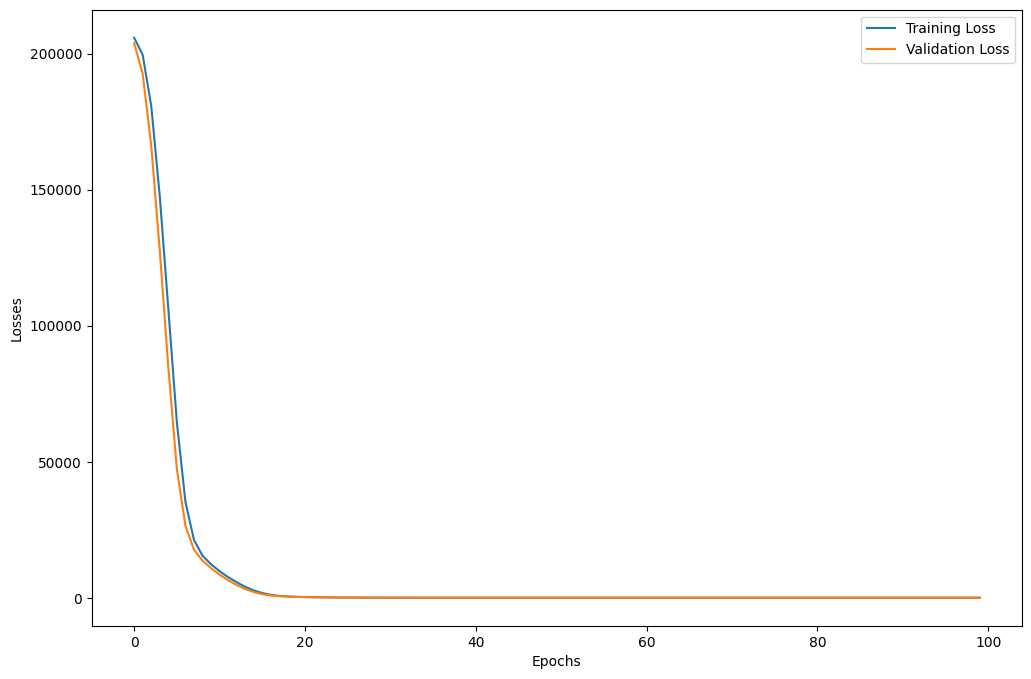

In [21]:
import matplotlib.pyplot as plt
loss_df = pd.DataFrame({
     "Training Loss":train_losses,
     "Validation Loss":valid_losses
})

plt.figure(figsize=(12,8))
plt.plot(loss_df["Training Loss"],label="Training Loss")
plt.plot(loss_df["Validation Loss"],label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()

In [22]:
## Loading best Model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [23]:
## Evaluate Our Model
model.eval()
with torch.no_grad():
     train_preds = model(X_train_tensor)
     test_preds = model(X_test_tensor)

     train_mse_loss = crietrian(train_preds,y_train_tensor)
     test_mse_loss = crietrian(test_preds,y_test_tensor)

print(f"Training MSE:{train_mse_loss.item()}")
print(f"Testing MSE:{test_mse_loss.item()}")

Training MSE:20.363346099853516
Testing MSE:18.719608306884766


In [25]:
from sklearn.metrics import r2_score
print(f"R2 Score:{r2_score(y_test,test_preds)*100}%")

R2 Score:93.45798006212426%


In [29]:
import pandas as pd

predicted_df = pd.DataFrame(
    test_preds.detach().numpy(),
    columns=["Predicted Values"]
)

actual_df = pd.DataFrame(
    y_test.to_numpy().reshape(-1,1),
    columns=["Actual Values"]
)

final_df = pd.concat([predicted_df, actual_df], axis=1)

final_df.head()

,Predicted Values,Actual Values
0,435.021149,433.27
1,436.767731,438.16
2,461.154877,458.42
3,476.412445,480.82
4,434.773682,441.41


***
- ***ANN For Classification***